In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [9]:
import os

DATASET_PATH = "/content/drive/MyDrive/datasets/rwf2000"
os.listdir(DATASET_PATH)

['val', 'train']

In [10]:
import os
import pandas as pd

data = []

# iterate over both splits
for split in ["train", "val"]:
    # use actual folder names in your dataset
    for label_folder, label_name in [("Fight", "attack"), ("NonFight", "non_attack")]:
        folder = os.path.join(DATASET_PATH, split, label_folder)
        if not os.path.exists(folder):
            print(f"Folder not found: {folder}")
            continue

        for file in os.listdir(folder):
            if file.endswith((".mp4", ".avi")):
                data.append({
                    "path": os.path.join(folder, file),
                    "label": label_name,  # standardized label
                    "split": split
                })

# create DataFrame
df = pd.DataFrame(data)
print(f"Total videos loaded: {len(df)}")
print(df.head())


Total videos loaded: 2000
                                                path   label  split
0  /content/drive/MyDrive/datasets/rwf2000/train/...  attack  train
1  /content/drive/MyDrive/datasets/rwf2000/train/...  attack  train
2  /content/drive/MyDrive/datasets/rwf2000/train/...  attack  train
3  /content/drive/MyDrive/datasets/rwf2000/train/...  attack  train
4  /content/drive/MyDrive/datasets/rwf2000/train/...  attack  train


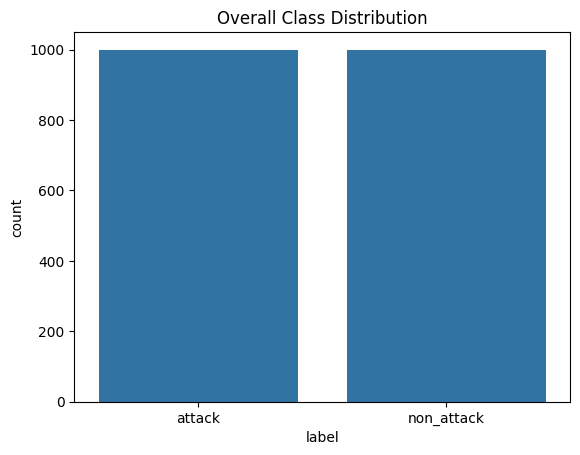

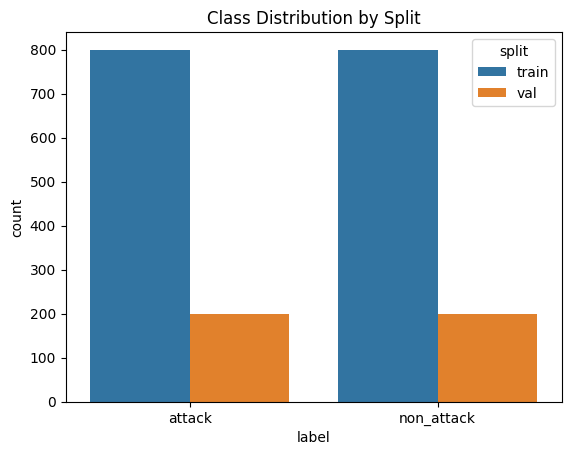

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Class distribution overall
sns.countplot(x="label", data=df)
plt.title("Overall Class Distribution")
plt.show()

# Class distribution by split
sns.countplot(x="label", hue="split", data=df)
plt.title("Class Distribution by Split")
plt.show()


In [12]:
import cv2

durations, fps_list, widths, heights = [], [], [], []

for path in df["path"]:
    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        durations.append(None)
        fps_list.append(None)
        widths.append(None)
        heights.append(None)
        continue

    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 1
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration = frames / fps

    durations.append(duration)
    fps_list.append(fps)
    widths.append(width)
    heights.append(height)
    cap.release()

df["duration_sec"] = durations
df["fps"] = fps_list
df["width"] = widths
df["height"] = heights
df.describe()


,duration_sec,fps,width,height
count,2000.0,2000.0,2000.000000,2000.000000
mean,5.0,30.0,724.245000,445.330000
std,0.0,0.0,439.697383,225.650886
min,5.0,30.0,204.000000,188.000000
25%,5.0,30.0,320.000000,240.000000
50%,5.0,30.0,527.000000,360.000000
75%,5.0,30.0,1280.000000,720.000000
max,5.0,30.0,1920.000000,1080.000000


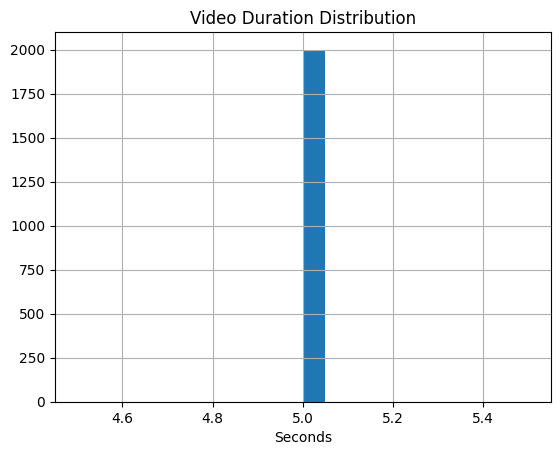

In [15]:
# Duration distribution
df["duration_sec"].hist(bins=20)
plt.title("Video Duration Distribution")
plt.xlabel("Seconds")
plt.show()


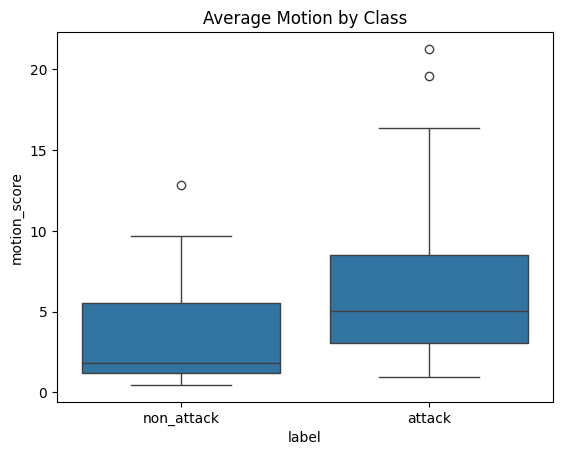

In [16]:
import numpy as np

def motion_score(video_path, step=5):
    cap = cv2.VideoCapture(video_path)
    ret, prev = cap.read()
    if not ret:
        return 0
    prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)
    scores = []

    while True:
        for _ in range(step - 1):
            cap.read()
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        diff = cv2.absdiff(gray, prev_gray)
        scores.append(diff.mean())
        prev_gray = gray
    cap.release()
    return np.mean(scores)

# Compute motion score for a subset (e.g., first 100 videos to save time)
df_subset = df.sample(100, random_state=42)
df_subset["motion_score"] = df_subset["path"].apply(motion_score)

sns.boxplot(x="label", y="motion_score", data=df_subset)
plt.title("Average Motion by Class")
plt.show()
